## NBA Player Position Predictor
### A data science/machine learning project to predict player positions from rate stats

In [2]:
import nba_api.stats.endpoints as endpoints
print(dir(endpoints))

['AllTimeLeadersGrids', 'AssistLeaders', 'AssistTracker', 'BoxScoreAdvancedV2', 'BoxScoreAdvancedV3', 'BoxScoreDefensiveV2', 'BoxScoreFourFactorsV2', 'BoxScoreFourFactorsV3', 'BoxScoreHustleV2', 'BoxScoreMatchupsV3', 'BoxScoreMiscV2', 'BoxScoreMiscV3', 'BoxScorePlayerTrackV3', 'BoxScoreScoringV2', 'BoxScoreScoringV3', 'BoxScoreSummaryV2', 'BoxScoreSummaryV3', 'BoxScoreTraditionalV2', 'BoxScoreTraditionalV3', 'BoxScoreUsageV2', 'BoxScoreUsageV3', 'CommonAllPlayers', 'CommonPlayerInfo', 'CommonPlayoffSeries', 'CommonTeamRoster', 'CommonTeamYears', 'CumeStatsPlayer', 'CumeStatsPlayerGames', 'CumeStatsTeam', 'CumeStatsTeamGames', 'DefenseHub', 'DraftBoard', 'DraftCombineDrillResults', 'DraftCombineNonStationaryShooting', 'DraftCombinePlayerAnthro', 'DraftCombineSpotShooting', 'DraftCombineStats', 'DraftHistory', 'DunkScoreLeaders', 'FantasyWidget', 'FranchiseHistory', 'FranchiseLeaders', 'FranchisePlayers', 'GLAlumBoxScoreSimilarityScore', 'GameRotation', 'GravityLeaders', 'HomePageLeaders

In [3]:
# now we can see a few options for what to import specifically
from nba_api.stats.endpoints import playerindex 

player_index = playerindex.PlayerIndex(season = '2024-25')
player_index_df = player_index.get_data_frames()[0]

print(player_index_df.columns.tolist())

['PERSON_ID', 'PLAYER_LAST_NAME', 'PLAYER_FIRST_NAME', 'PLAYER_SLUG', 'TEAM_ID', 'TEAM_SLUG', 'IS_DEFUNCT', 'TEAM_CITY', 'TEAM_NAME', 'TEAM_ABBREVIATION', 'JERSEY_NUMBER', 'POSITION', 'HEIGHT', 'WEIGHT', 'COLLEGE', 'COUNTRY', 'DRAFT_YEAR', 'DRAFT_ROUND', 'DRAFT_NUMBER', 'ROSTER_STATUS', 'FROM_YEAR', 'TO_YEAR', 'PTS', 'REB', 'AST', 'STATS_TIMEFRAME']


In [4]:
print(player_index_df['POSITION'].value_counts())
# it seems like not all of the players are present, let's confirm

POSITION
G      66
F      45
C       8
G-F     7
C-F     5
F-C     4
F-G     2
Name: count, dtype: int64


In [5]:
print(player_index_df.shape)
print(player_index_df['ROSTER_STATUS'].value_counts())
# yup, we're missing most of the league

(137, 26)
ROSTER_STATUS
1.0    103
Name: count, dtype: int64


In [6]:
player_index_all = playerindex.PlayerIndex()
player_index_all_df = player_index_all.get_data_frames()[0]

print(player_index_all_df.shape)
print(player_index_all_df['POSITION'].value_counts())
# this is the fix

(584, 26)
POSITION
G      244
F      178
C       65
G-F     39
F-C     30
C-F     17
F-G     11
Name: count, dtype: int64


In [7]:
print(player_index_all_df[['PLAYER_FIRST_NAME', 'PLAYER_LAST_NAME', 'POSITION', 'FROM_YEAR', 'TO_YEAR']].head(20))
# now everyone is up to date for the 2024-25 season

   PLAYER_FIRST_NAME  PLAYER_LAST_NAME POSITION FROM_YEAR TO_YEAR
0           Precious           Achiuwa        F      2020    2025
1             Steven             Adams        C      2013    2025
2                Bam           Adebayo      C-F      2017    2025
3              Ochai            Agbaji        G      2022    2025
4              Santi            Aldama      F-C      2021    2025
5               Trey         Alexander        G      2024    2025
6            Nickeil  Alexander-Walker        G      2019    2025
7            Grayson             Allen        G      2018    2025
8            Jarrett             Allen        C      2017    2025
9               Jose          Alvarado        G      2021    2025
10              Kyle          Anderson      F-G      2014    2025
11              Alex     Antetokounmpo        F      2025    2025
12           Giannis     Antetokounmpo        F      2013    2025
13          Thanasis     Antetokounmpo        F      2015    2025
14        

In [ ]:
from nba_api.stats.endpoints import leaguedashplayerstats, playerindex
import pandas as pd

# pulling player stats for the 2024-25 season
stats = leaguedashplayerstats.LeagueDashPlayerStats(season='2024-25')
df = stats.get_data_frames()[0]

print(df.shape)

(569, 67)


In [ ]:
# grabbing just the columns we need from the position table
positions = player_index_all_df[['PERSON_ID', 'POSITION']]

# merging with our stats table
df_merged = df.merge(positions, left_on='PLAYER_ID', right_on='PERSON_ID', how='left')

print(df_merged.shape)
print(df_merged['POSITION'].value_counts())

(569, 69)
POSITION
G      186
F      144
C       48
G-F     33
F-C     29
C-F     17
F-G     11
Name: count, dtype: int64


In [10]:
# the merge worked, but there are about 101 platers that don't have position data
# let's confirm real quick
print(df_merged['POSITION'].isna().sum())

101


In [11]:
# yup, 101 are missing; we should check who these guys are before we do anything
# let's see how many games + minutes they played
df_merged[df_merged['POSITION'].isna()][['PLAYER_NAME', 'MIN', 'GP']].head(20)

,PLAYER_NAME,MIN,GP
7,Adam Flagler,202.965000,37
8,Adama Sanogo,21.498333,4
12,Alec Burks,863.496667,49
14,Alex Ducas,125.341667,21
15,Alex Len,379.790000,46
16,Alex Reese,216.046667,15
31,Anton Watson,22.166667,9
34,Armel Traore,66.666667,9
41,Ben Simmons,1119.693333,51
49,Bol Bol,448.483333,36


In [12]:
# there are some pretty big names; let's try out another API endpoint to look for positions
from nba_api.stats.endpoints import commonplayerinfo

test = commonplayerinfo.CommonPlayerInfo(player_id=1627732)
test_df = test.get_data_frames()[0]
print(test_df[['DISPLAY_FIRST_LAST', 'POSITION']].head())
# test with Ben Simmons

  DISPLAY_FIRST_LAST       POSITION
0        Ben Simmons  Guard-Forward


In [ ]:
import time

# start by getting the player IDs that are missing position data
missing_ids = df_merged[df_merged['POSITION'].isna()]['PLAYER_ID'].tolist()

# now we can loop through each one and grab their position
position_fixes = []

for player_id in missing_ids:
    try:
        info = commonplayerinfo.CommonPlayerInfo(player_id=player_id)
        info_df = info.get_data_frames()[0]
        position = info_df['POSITION'].values[0]
        position_fixes.append({'PLAYER_ID': player_id, 'POSITION_FIX': position})
        time.sleep(0.5)  # pause to avoid hitting the API too fast
    except:
        position_fixes.append({'PLAYER_ID': player_id, 'POSITION_FIX': None})

fixes_df = pd.DataFrame(position_fixes)
print(fixes_df['POSITION_FIX'].value_counts())

POSITION_FIX
Guard             46
Forward           34
Center             6
Guard-Forward      6
Center-Forward     4
Forward-Center     3
Forward-Guard      2
Name: count, dtype: int64


In [ ]:
# merging the fixes into our main dataframe
df_merged = df_merged.merge(fixes_df, on='PLAYER_ID', how='left')

# filling in in missing positions with the fixes
df_merged['POSITION'] = df_merged['POSITION'].fillna(df_merged['POSITION_FIX'])

print(df_merged['POSITION'].isna().sum())

0


In [ ]:
# great, now everything is merged!
print(df_merged['POSITION'].value_counts())

POSITION
G                 186
F                 144
C                  48
Guard              46
Forward            34
G-F                33
F-C                29
C-F                17
F-G                11
Center              6
Guard-Forward       6
Center-Forward      4
Forward-Center      3
Forward-Guard       2
Name: count, dtype: int64


In [20]:
position_map = {
    'G': 'G',
    'F': 'F', 
    'C': 'C',
    'Guard': 'G',
    'Forward': 'F',
    'Center': 'C',
    'G-F': 'G',
    'F-C': 'F',
    'C-F': 'C',
    'F-G': 'F',
    'Guard-Forward': 'G',
    'Center-Forward': 'C',
    'Forward-Center': 'F',
    'Forward-Guard': 'F'
}

df_merged['POSITION'] = df_merged['POSITION'].map(position_map)
print(df_merged['POSITION'].value_counts())
print(df_merged['POSITION'].isna().sum())

POSITION
G    271
F    223
C     75
Name: count, dtype: int64
0


In [21]:
# now that everything is merged, we should set a baseline amount of minutes
# I'm going with 200, since that's about 5 minutes/game over 40 games
df_clean = df_merged[df_merged['MIN'] >= 200].copy()
print(df_clean.shape)
print(df_clean['POSITION'].value_counts())

(457, 70)
POSITION
G    222
F    170
C     65
Name: count, dtype: int64


In [23]:
# now that we have a strong dataset we can move onto rate stats
# I'm going with rate stats per 36 minutes, since that is about the typical
# workload of an NBA starter

# Calculate per-36 minute stats
df_clean['PTS_36'] = df_clean['PTS'] / df_clean['MIN'] * 36
df_clean['AST_36'] = df_clean['AST'] / df_clean['MIN'] * 36
df_clean['REB_36'] = df_clean['REB'] / df_clean['MIN'] * 36
df_clean['OREB_36'] = df_clean['OREB'] / df_clean['MIN'] * 36
df_clean['DREB_36'] = df_clean['DREB'] / df_clean['MIN'] * 36
df_clean['STL_36'] = df_clean['STL'] / df_clean['MIN'] * 36
df_clean['BLK_36'] = df_clean['BLK'] / df_clean['MIN'] * 36
df_clean['TOV_36'] = df_clean['TOV'] / df_clean['MIN'] * 36

# Calculate shooting profile stats
df_clean['3PA_RATE'] = df_clean['FG3A'] / df_clean['FGA']
df_clean['FTA_RATE'] = df_clean['FTA'] / df_clean['FGA']
df_clean['TS_PCT'] = df_clean['PTS'] / (2 * (df_clean['FGA'] + 0.44 * df_clean['FTA']))

print(df_clean[['PTS_36', 'AST_36', 'REB_36', 'BLK_36', '3PA_RATE', 'TS_PCT']].head())

      PTS_36    AST_36    REB_36    BLK_36  3PA_RATE    TS_PCT
0  17.466746  2.294361  6.365001  0.444070  0.531579  0.541981
1  11.738600  2.343380  3.775446  0.151886  0.856132  0.620584
2  12.406274  4.285804  3.327137  0.169176  0.422535  0.479763
3  18.613182  4.080965  6.146331  0.348375  0.346076  0.649576
4  15.449734  3.771553  3.544351  0.499844  0.675373  0.594322


In [ ]:
# it worked well! these stats represent each player's statline if each player
# player 36 minutes/game; this makes it proportional so we can truly analyze
# efficiency

# now we need to build our feauture matrix, so let's start with the features
features = [
    'PTS_36', 'AST_36', 'REB_36', 'OREB_36', 'DREB_36',
    'STL_36', 'BLK_36', 'TOV_36', '3PA_RATE', 'FTA_RATE', 'TS_PCT'
]

# building X (the features) and y (the target)
X = df_clean[features]
y = df_clean['POSITION']

print(X.shape)
print(y.value_counts())

(457, 11)
POSITION
G    222
F    170
C     65
Name: count, dtype: int64


In [ ]:
# we have evrything good to go! now we can split the data and into training sets
# and test sets to train the Logistic Regression model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# splitting data into 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# training logistic regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# now let's look at the model
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.74
              precision    recall  f1-score   support

           C       0.69      0.73      0.71        15
           F       0.71      0.63      0.67        38
           G       0.79      0.85      0.81        39

    accuracy                           0.74        92
   macro avg       0.73      0.74      0.73        92
weighted avg       0.74      0.74      0.74        92



In [ ]:
# the results are looking pretty good! the model is especially good at
# predicting guards, and surprisignly accurate at predicting centers, despite
# the lack of support when compared to the other two positions
# if I had to take an initial guess as to why, it would be because the modern
# day forward is more positionless than centers and guards, and therefore
# harder to identify

# now let's try the random forest model
from sklearn.ensemble import RandomForestClassifier

# tradining the random forest 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# now let's look at the results
rf_pred = rf_model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.2f}")
print(classification_report(y_test, rf_pred))

Accuracy: 0.74
              precision    recall  f1-score   support

           C       0.67      0.80      0.73        15
           F       0.71      0.63      0.67        38
           G       0.80      0.82      0.81        39

    accuracy                           0.74        92
   macro avg       0.72      0.75      0.73        92
weighted avg       0.74      0.74      0.74        92



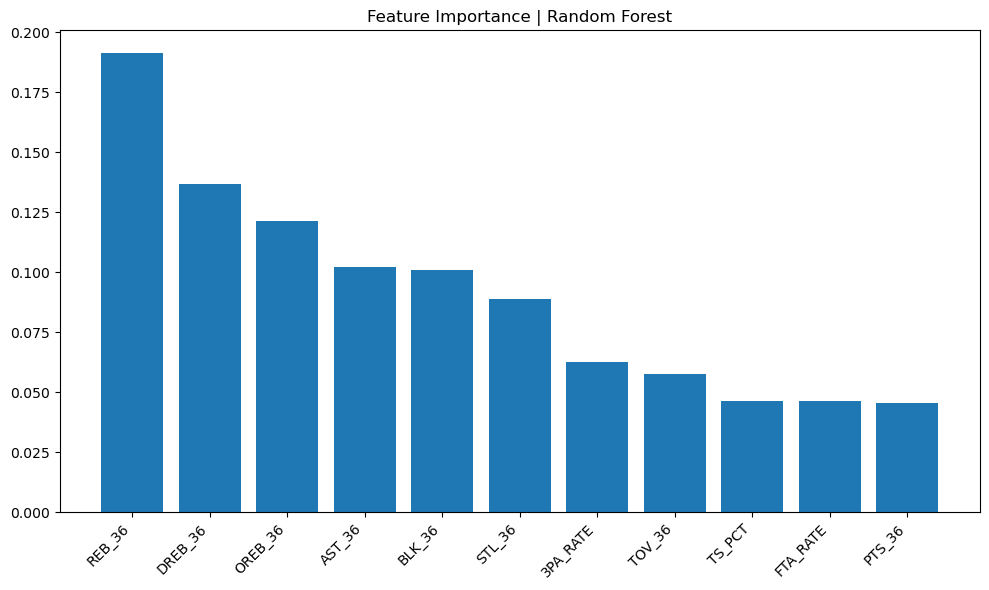

In [29]:
# the random forest also has an accuracy of 0.74, and the results are almost
# identical; this suggest that we have hit the accuracy ceiling with our current
# data, despite the choice of model

# let's look at the most important feautures now
import matplotlib.pyplot as plt
import numpy as np

# getting the importances of features from random forest
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(features)), importances[indices])
plt.xticks(range(len(features)), [features[i] for i in indices], rotation=45, ha='right')
plt.title("Feature Importance | Random Forest")
plt.tight_layout()
plt.show()

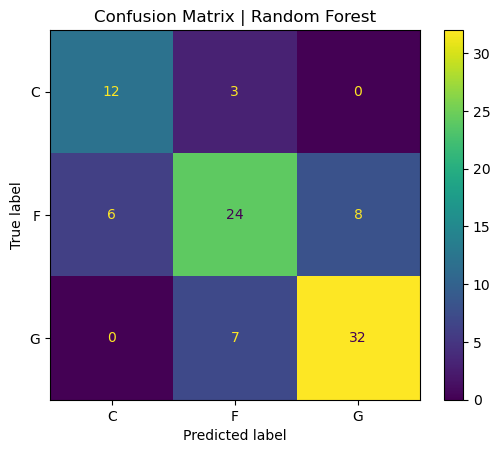

In [31]:
# initial observations: rebounds are far and away the most important score
# (dominating the top 3), which makes sense because it is the main separator
# between guards and big men
# we can also see that true shooting, free throw attempts rate, and points are
# dead last; this is likely due to the fact that in today's league, everyone --
# regardless of position -- can score, and players who are scoring alot also
# draw more fouls

# now let's look at the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, display_labels=['C', 'F', 'G'])
plt.title('Confusion Matrix | Random Forest')
plt.show()

In [33]:
# interesting, we have a few things to look at here:
# centers: 12 correct and 3 misclassified as forwards, with none misclassified
# as guards, which makes sense since very few center play like guards (if any)
# guards: 32 correct, 7 misclassified as forwards, 0 as centers; this is the
# same pattern, which checks out
# forwards: 24 correct, but 6 misclassified as centers and 8 misclassified as
# guards; this further shows that they are the hardest position to identify
# I would guess that this is because of the blurred lines-playstyle of forwards,
# and it might be exacerbated by the fact that SF (which play a bit more like 
# guards) and PF (which play a bit more like centers) are combined into one 
# category

# now let's look at who actually got misclassified
# adding predictions to a copy of X_test
df_test = X_test.copy()
df_test['PLAYER_NAME'] = df_clean.loc[X_test.index, 'PLAYER_NAME'].values
df_test['POSITION'] = y_test.values
df_test['PREDICTED'] = rf_pred

# showing misclassified players
misclassified = df_test[df_test['POSITION'] != df_test['PREDICTED']]
print(misclassified[['PLAYER_NAME', 'POSITION', 'PREDICTED']])

           PLAYER_NAME POSITION PREDICTED
267       Jerami Grant        F         G
35      Ausar Thompson        G         F
202     Isaiah Stewart        F         C
434     Oscar Tshiebwe        F         C
455      Peyton Watson        G         F
140       Desmond Bane        G         F
93       Cody Williams        F         G
300        Josh Okogie        G         F
562       Zach Collins        F         C
338    Khris Middleton        F         G
396       Micah Potter        C         F
109      Dalano Banton        F         G
288     Jordan Goodwin        G         F
362   Lindy Waters III        F         G
315     Karlo Matković        F         C
38         Bam Adebayo        C         F
299        Josh Minott        F         G
12          Alec Burks        G         F
17           Alex Sarr        C         F
0          A.J. Lawson        G         F
366        Luka Dončić        F         G
28       Anthony Davis        F         C
557     Xavier Tillman        F   

In [ ]:
# there are a good amount of big names in here, and their positions are actually
# debatable, too
# first is Luka, who was predicted as a G but classified as a F; I would agree with
# the model here, he plays much more like a guard -- and a point guard, too, he is
# typically the one taking the ball up the court
# then there's Bam, who was predicted as a F but classified as a C; I would agree
# with the model again, he doesn't fit the C mold at all
# Wemby is also questionable -- he can do absolutely everything, and his insane 
# number of blocks definitely classified him as a C; I would stand with the model
# here since it predicted C but his listed position is F (he can do everything,
# though so this is more debatable)
# I would also argue that AD's listed position is incorrect (F vs C)

# other notable players that could be debated are Krhis Middleton, Jerami Grant,
# and Ausar Thompson

# many of these predictions aren't mistakes, though, the model is siply disagreeing
# with the classifications of certain players

## Conclusions

### Model Performance
Both logistic regression and random forest achieved 74% accuracy on the test set, 
correctly predicting NBA player positions from rate stats alone. Given that random 
guessing would yield about 33% accuracy on a 3-class problem, this is a strong result.

### Key Findings
1. Forwards are the hardest position to predict:
Every single misclassification 
involved a Forward, never a Center-Guard confusion. This reflects the reality of the 
modern NBA where the Forward position is a spectrum between Guard and Center archetypes.

2. Rebounding is the most important feature:
REB_36, DREB_36, and OREB_36 were 
the top three features, cleanly separating big men from guards.

3. Scoring doesn't define position
PTS_36 and TS_PCT were the least important 
features, confirming that players at every position can score at similar rates.

4. The model often disagress with official labels: notable "misclassifications" are 
Luka Dončić (F->G), Victor Wembanyama (F->C), and Bam Adebayo (C->F) suggesting the model 
captures how players actually play better than their official NBA position designations.

### Limitations
- Position labels from the NBA API are imperfect and inconsistently
- Collapsing 5 positions into 3 loses nuance (PG vs SG, PF vs SF)
- A larger dataset with multiple seasons could improve the accuracy of these models

### Next Steps
- Test on 2023-24 season data to look at generalizability
- Explore 5-class classification (PG, SG, SF, PF, C)